In [ ]:
pip install pandas numpy matplotlib scikit-learn xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/150.0 MB 1.1 MB/s eta 0:02:23
   ---------------------------------------- 0.5/150.0 MB 4.3 MB/s eta 0:00:36
   ---------------------------------------- 1.1/150.0 MB 6.6 MB/s eta 0:00:23
    --------------------------------------- 2.0/150.0 MB 8.3 MB/s eta 0:00:18
    --------------------------------------- 3.1/150.0 MB 11.0 MB/s eta 0:00:14
   - -------------------------------------- 4.3/150.0 MB 13.0 MB/s eta 0:00:12
   - -------------------------------------- 4.5/150.0 MB 12.4 MB/s eta 0:00:12
   - -------------------------------------- 4.9/150.0 MB 11.6 MB/s eta 0:00:13
   - -------------------------------------- 6.3/150.0 MB 13.4 MB/s eta 0:00:11
   - -------------------------------------- 7.1/150.0 MB 13.8 MB/s eta 0:00:11
   -- ------------------------------------- 8.0/150.0 MB 14.6 MB/s eta 0


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\gunja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   ---------- ---------------------------- 81.9/294.9 kB 762.6 kB/s eta 0:00:01
   ---------------------------------- ----- 256.0/294.9 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\gunja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load EDA and HR data
eda_df = pd.read_csv("C:/Users/gunja/Desktop/Tecnomers internship/systematic lit review/WESAD DATA analysis/S4/EDA.csv",skiprows=2, header=None, names=["EDA"])
hr_df = pd.read_csv("C:/Users/gunja/Desktop/Tecnomers internship/systematic lit review/WESAD DATA analysis/S4/HR.csv",skiprows=2,header=None,names=["HR"])

# === 2. Define window size (e.g., 60 samples per window) ===
window_size = 60  # assuming 4 Hz sampling for EDA, ~1 Hz for HR
num_windows = min(len(eda_df), len(hr_df)) // window_size

features = []
labels = []

# === 3. Extract statistical features per window ===
for i in range(num_windows):
    #Defines the start and end indices of the current window
    start = i * window_size
    end = start + window_size
    
    eda_window = eda_df["EDA"][start:end]
    hr_window = hr_df["HR"][start:end]
    
    if len(eda_window) < window_size or len(hr_window) < window_size:
        continue
    
    feature_vector = [
        eda_window.mean(), #.mean() computes the arithmetic mean of those samples.
        eda_window.std(),
        hr_window.mean(),
        hr_window.std()
    ]
    features.append(feature_vector) #feature_vector is added to feature list
    
    # Simulated labels: 0 = rest, 1 = mental task, 2 = physical
    # Repeat pattern or assign randomly for demonstration
    labels.append(i % 3)

# === 4. Convert to DataFrame ===
X = pd.DataFrame(features, columns=["EDA_mean", "EDA_std", "HR_mean", "HR_std"])
y = np.array(labels)

# === 5. Split data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size=0.2	20% of the data goes to testing, 80% to training
#random_state=42	ensures you get the same split every time


C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [23:56:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.17      0.22        12
           1       0.27      0.38      0.32         8
           2       0.20      0.29      0.24         7

    accuracy                           0.26        27
   macro avg       0.27      0.28      0.26        27
weighted avg       0.28      0.26      0.25        27

Confusion Matrix:


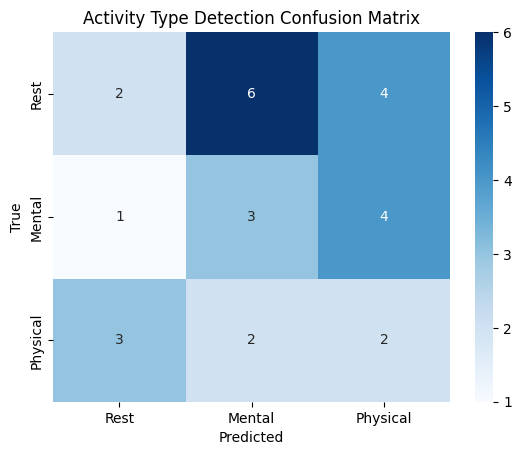

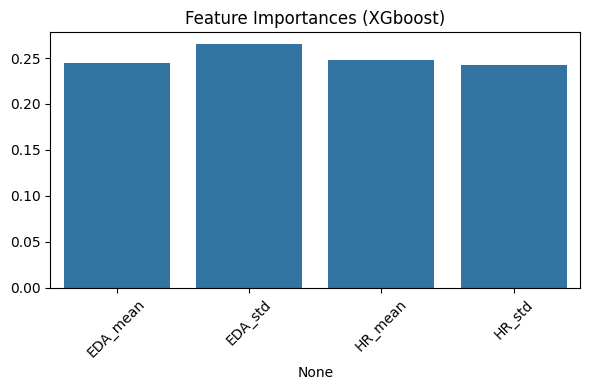

In [ ]:
# === 6. Train model (choose one) ===

# Random Forest
#rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
#rf_model.fit(X_train, y_train)
#y_pred = rf_model.predict(X_test)



# XGBoost (uncomment if using this instead)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# === 7. Evaluate ===
print("Classification Report:")
print(classification_report(y_test, y_pred))
#The classification_report from sklearn.metrics gives a detailed summary of how well a classifier performed on each class and overall.
#"precision    recall  f1-score   support  --> column metric"
#accuracy macro avg weighted avg --> row metric"
     

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rest", "Mental", "Physical"], yticklabels=["Rest", "Mental", "Physical"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Activity Type Detection Confusion Matrix")
plt.show()

# === 8. Feature Importance ===
importances = xgb_model.feature_importances_
plt.figure(figsize=(6,4))
sns.barplot(x=X.columns, y=importances)
plt.title("Feature Importances (XGboost)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost (uncomment if using this instead)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# === 7. Evaluate ===
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rest", "Mental", "Physical"], yticklabels=["Rest", "Mental", "Physical"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Activity Type Detection Confusion Matrix")
plt.show()

# === 8. Feature Importance ===
importances = xgb_model.feature_importances_
plt.figure(figsize=(6,4))
sns.barplot(x=X.columns, y=importances)
plt.title("Feature Importances (XGboost)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.17      0.22        12
           1       0.27      0.38      0.32         8
           2       0.20      0.29      0.24         7

    accuracy                           0.26        27
   macro avg       0.27      0.28      0.26        27
weighted avg       0.28      0.26      0.25        27



C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [00:40:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)



# === 7. Evaluate ===
print("Classification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00         8
           2       0.26      1.00      0.41         7

    accuracy                           0.26        27
   macro avg       0.09      0.33      0.14        27
weighted avg       0.07      0.26      0.11        27



C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00         8
           2       0.26      1.00      0.41         7

    accuracy                           0.26        27
   macro avg       0.09      0.33      0.14        27
weighted avg       0.07      0.26      0.11        27

Confusion Matrix:


C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gunja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

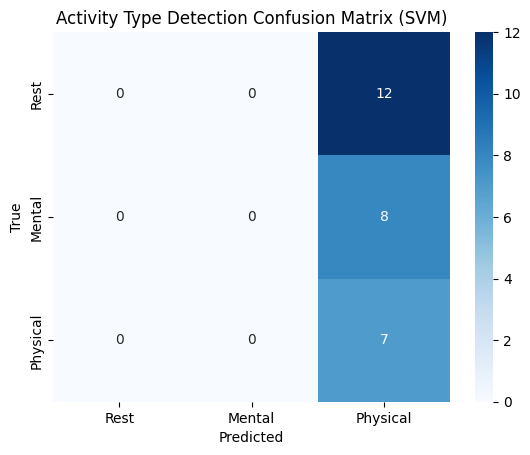

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# === 7. Evaluate ===
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rest", "Mental", "Physical"],
            yticklabels=["Rest", "Mental", "Physical"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Activity Type Detection Confusion Matrix (SVM)")
plt.show()
